# ***PRIVACIDAD Y FEDERATED LEARNING***

En esta sección se va a tratar la problemática de privacidad y Federated Learning. Esta problemática es importante en este proyecto porque el dataset utilizado contiene información de pacientes. Aunque el dataset esté anonimizado, en un contexto real estos datos serían muy sensibles, por lo que no sería adecuado mover toda la información de los pacientes a un único servidor central sin una justificación clara.

Además, el propio origen del dataset hace que esta problemática tenga sentido. Los datos proceden de múltiples hospitales, por lo que en un escenario real cada hospital tendría sus propios registros y podría no querer compartirlos directamente con otros centros. Sin embargo, todos los hospitales podrían beneficiarse de entrenar un modelo común capaz de predecir el reingreso hospitalario. Aquí es donde entra el aprendizaje federado, ya que permite entrenar modelos de forma distribuida, es decir, cada hospital entrena el modelo con sus propios datos locales y solo comparte información del modelo, no los datos originales de los pacientes.

El objetivo de esta parte no es tanto mejorar las métricas respecto al modelo centralizado, sino analizar si se puede obtener un rendimiento razonable manteniendo una mayor privacidad. Es decir, se busca estudiar el equilibrio entre rendimiento y privacidad, ya que un modelo centralizado tiene acceso a todos los datos y, por tanto, suele aprender mejor, pero obliga a reunir la información de todos los hospitales en un mismo lugar. 

En esta parte se utilizará el dataset original desbalanceado, y no el dataset balanceado con SMOTE. La razón es que el objetivo de Federated Learning es simular un escenario hospitalario real. En la práctica, los hospitales no tendrían clases perfectamente balanceadas, sino sus propias distribuciones de pacientes y de reingresos. Además, ya se ha observado que balancear el dataset no aporta cambios muy significativos en el rendimiento de los modelos, de forma que se prefiere una simulación más realista en este caso.

Por tanto, esta parte del trabajo se centra en comprobar si un enfoque federado puede ser una alternativa viable en un problema clínico como el planteado.

Se ha decidido evaluar distintas alternativas de modelos para implementar el enfoque de aprendizaje federado. En primer lugar, se utilizó un "SGDClassifier", ya que conceptualmente es compatible con este enfoque federado. Al tratarse de un modelo entrenado mediante descenso de gradiente, permite simular de forma sencilla el esquema clásico de Federated Learning, es decir, cada cliente entrena localmente el modelo con sus propios datos y posteriormente se agregan los parámetros aprendidos. A diferencia de los modelos basados en árboles, como "XGBoost", cuyos mecanismos de entrenamiento federado son más complejos y menos directos de implementar.

No obstante, también se ha incorporado posteriormente un modelo "XGBoost" en el escenario federado, con el objetivo de realizar una comparación más directa con el baseline. De este modo, el "SGDClassifier" se emplea como una aproximación más simple e interpretable para comprender el funcionamiento del aprendizaje federado, mientras que "XGBoost" permite analizar si el modelo puede mantener un rendimiento comparable al baseline bajo una configuración federada, donde hay una mayor privacidad.

Asimismo, durante la revisión de trabajos relacionados se observó que en muchos estudios sobre Federated Learning aplicado a este dataset se emplean redes neuronales. Por este motivo, se implementó y evaluó la arquitectura propuesta en el artículo Prediction of Hospital Readmission using Federated Learning. Sin embargo, los resultados obtenidos no fueron buenos, alcanzando un F1-score de 0.232011. Debido a este bajo rendimiento, y teniendo en cuenta que el objetivo principal del proyecto es analizar técnicas de aprendizaje automático clásico y no modelos de Deep Learning, se decidió no incluir finalmente esta aproximación. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
import os
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")
import ray
import flwr as fl
import tempfile
from pathlib import Path
from flwr.common import (FitIns,EvaluateIns,ndarrays_to_parameters,parameters_to_ndarrays,)
from flwr.server.strategy import Strategy

In [15]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

y = df["readmitted"]
X = df.drop(columns=["readmitted"])

X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

In [16]:
X_train_np = X_train.to_numpy() if hasattr(X_train, "to_numpy") else np.asarray(X_train)
X_test_np = X_test.to_numpy() if hasattr(X_test, "to_numpy") else np.asarray(X_test)

y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.asarray(y_train)
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

classes = np.unique(y_train_np)

Para implementar el aprendizaje federado, lo primero que se debe hacer es simular los clientes federados, que representan los distintos hospitales. La idea es dividir el conjunto de entrenamiento en varias partes para que el modelo no se entrene directamente con todos los datos centralizados, sino como si cada hospital tuviera únicamente sus propios pacientes.

Para hacer esta división se crean cinco clientes, y cada uno recibe una parte del conjunto de entrenamiento, manteniendo sus propias etiquetas. La división se realiza de forma estratificada, para que cada cliente tenga una distribución de clases parecida a la del conjunto original. 

Se ha decidido simular el aprendizaje federado utilizando 5 clientes, ya que si se usaran muy pocos clientes, la simulación se parecería demasiado a un entrenamiento centralizado, pero si se usaran demasiados, cada cliente tendría menos datos disponibles y el entrenamiento podría volverse menos estable. 

Por lo tanto, a partir de este punto, los datos dejan de tratarse como un único conjunto y pasan a estar repartidos entre varios hospitales. Esto permite representar mejor una situación real, donde cada hospital conserva sus datos localmente y no los comparte directamente con el resto. A partir de esta división, cada cliente podrá entrenar su propio modelo, y después se combinará la información aprendida para construir un modelo global sin tener que centralizar los datos.

In [17]:
def crear_clientes_federados(X, y, n_clients=5, random_state=42):
    skf = StratifiedKFold(
        n_splits=n_clients,
        shuffle=True,
        random_state=random_state
    )

    clientes = []

    for _, client_idx in skf.split(X, y):
        X_client = X[client_idx]
        y_client = y[client_idx]
        clientes.append((X_client, y_client))

    return clientes


n_clients = 5

clientes = crear_clientes_federados(
    X_train_np,
    y_train_np,
    n_clients=n_clients,
    random_state=42
)

Seguidamente se definen las funciones que permiten simular el proceso de Federated Learning. La idea general es que existe un modelo global, que se envía a varios clientes, cada cliente lo entrena con sus propios datos, y después se combinan los parámetros aprendidos para actualizar de nuevo el modelo global.

Primero se define la función de "agregación mediante FedAvg". Este método combina los parámetros entrenados por cada cliente calculando una media ponderada. No todos los clientes tienen el mismo número de pacientes, por lo que los modelos locales no se combinan dando el mismo peso a todos, sino teniendo en cuenta cuántas muestras tiene cada cliente. Así, un hospital simulado con más datos aporta más al modelo global que uno con menos datos.

También se define la función que entrena cada cliente. En este caso, cada cliente recibe los parámetros actuales del modelo global y los usa como punto de partida. Después, entrena el modelo únicamente con sus propios datos locales, sin acceder a los datos de los demás clientes. 

Por último, también se define una función para inicializar el modelo global, que se declara con sus coeficientes y, a partir de ahí, será enviado a los clientes, actualizado localmente.

In [18]:
def agregar_parametros_fedavg(parametros_clientes, tamanos_clientes):
    total_muestras = np.sum(tamanos_clientes)

    coef_global = np.zeros_like(parametros_clientes[0][0])
    intercept_global = np.zeros_like(parametros_clientes[0][1])

    for (coef_cliente, intercept_cliente), n_cliente in zip(parametros_clientes, tamanos_clientes):
        peso = n_cliente / total_muestras
        coef_global += peso * coef_cliente
        intercept_global += peso * intercept_cliente

    return coef_global, intercept_global

def entrenar_cliente(
    X_client,
    y_client,
    coef_global,
    intercept_global,
    classes,
    local_epochs=1,
    random_state=42
):
    modelo_local = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        learning_rate="optimal",
        max_iter=1,
        tol=None,
        random_state=random_state
    )

    X_dummy = np.zeros((len(classes), X_client.shape[1]))
    y_dummy = classes

    modelo_local.partial_fit(X_dummy, y_dummy, classes=classes)

    modelo_local.coef_ = coef_global.copy()
    modelo_local.intercept_ = intercept_global.copy()

    sample_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_client
    )

    rng = np.random.default_rng(random_state)

    for _ in range(local_epochs):
        indices = rng.permutation(len(y_client))

        modelo_local.partial_fit(
            X_client[indices],
            y_client[indices],
            classes=classes,
            sample_weight=sample_weights[indices]
        )

    return modelo_local.coef_, modelo_local.intercept_

def inicializar_modelo_global(n_features, classes):
    modelo = SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=0.0001,
        learning_rate="optimal",
        max_iter=1,
        tol=None,
        random_state=42
    )

    X_dummy = np.zeros((len(classes), n_features))
    y_dummy = classes

    modelo.partial_fit(X_dummy, y_dummy, classes=classes)

    modelo.coef_ = np.zeros_like(modelo.coef_)
    modelo.intercept_ = np.zeros_like(modelo.intercept_)

    return modelo

In [19]:
n_features = X_train_np.shape[1]
n_rounds = 20
local_epochs = 1

modelo_global = inicializar_modelo_global(
    n_features=n_features,
    classes=classes
)

historial_federado = []

for ronda in range(1, n_rounds + 1):
    parametros_clientes = []
    tamanos_clientes = []

    for client_id, (X_c, y_c) in enumerate(clientes):
        coef_c, intercept_c = entrenar_cliente(
            X_client=X_c,
            y_client=y_c,
            coef_global=modelo_global.coef_,
            intercept_global=modelo_global.intercept_,
            classes=classes,
            local_epochs=local_epochs,
            random_state=42 + ronda + client_id
        )

        parametros_clientes.append((coef_c, intercept_c))
        tamanos_clientes.append(len(y_c))

    coef_global, intercept_global = agregar_parametros_fedavg(
        parametros_clientes,
        tamanos_clientes
    )

    modelo_global.coef_ = coef_global
    modelo_global.intercept_ = intercept_global

    y_pred_ronda = modelo_global.predict(X_test_np)

    historial_federado.append({
        "Ronda": ronda,
        "Accuracy": accuracy_score(y_test_np, y_pred_ronda),
        "Precision Macro": precision_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "F1-Score Macro": f1_score(
            y_test_np,
            y_pred_ronda,
            average="macro",
            zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test_np,
            y_pred_ronda,
            average="weighted",
            zero_division=0
        )
    })

historial_federado_df = pd.DataFrame(historial_federado)

# Evaluación final tras la última ronda
y_pred_federado = modelo_global.predict(X_test_np)

resultados_sgd_federado = pd.DataFrame({
    "Modelo": ["SGDClassifier federado"],
    "Escenario": [f"Federated Learning con {n_clients} clientes simulados"],
    "Test Accuracy": [
        accuracy_score(y_test_np, y_pred_federado)
    ],
    "Precision Macro": [
        precision_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "Recall Macro": [
        recall_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "F1-Score Macro": [
        f1_score(
            y_test_np,
            y_pred_federado,
            average="macro",
            zero_division=0
        )
    ],
    "F1 Weighted": [
        f1_score(
            y_test_np,
            y_pred_federado,
            average="weighted",
            zero_division=0
        )
    ]
})

resultados_sgd_federado = resultados_sgd_federado.round(4)

resultados_sgd_federado

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier federado,Federated Learning con 5 clientes simulados,0.1373,0.1847,0.3359,0.1196,0.0791


Además del modelo federado, también se entrena un "SGDClassifier" pero en este caso centralizado para comparar ambos casos utilizando el mismo tipo de modelo. 

In [20]:
# MODELO CENTRALIZADO EQUIVALENTE
modelo_centralizado = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    learning_rate="optimal",
    max_iter=1000,
    tol=1e-3,
    random_state=42
)

sample_weights_train = compute_sample_weight(
    class_weight="balanced",
    y=y_train_np
)

modelo_centralizado.fit(
    X_train_np,
    y_train_np,
    sample_weight=sample_weights_train
)

y_pred_centralizado = modelo_centralizado.predict(X_test_np)

resultados_sgd_centralizado = pd.DataFrame({
    "Modelo": ["SGDClassifier centralizado"],
    "Escenario": ["Datos centralizados"],
    "Test Accuracy": [
        accuracy_score(y_test_np, y_pred_centralizado)
    ],
    "Precision Macro": [
        precision_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "Recall Macro": [
        recall_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "F1-Score Macro": [
        f1_score(
            y_test_np,
            y_pred_centralizado,
            average="macro",
            zero_division=0
        )
    ],
    "F1 Weighted": [
        f1_score(
            y_test_np,
            y_pred_centralizado,
            average="weighted",
            zero_division=0
        )
    ]
})

resultados_sgd_centralizado = resultados_sgd_centralizado.round(4)

resultados_sgd_centralizado

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier centralizado,Datos centralizados,0.1135,0.1451,0.3315,0.0693,0.0259


A continuación ya se implementa el aprendizaje federato utilizando el modelo XGBoost, para lo que se utiliza la herramienta Flower. Debido a que esta implementación es más compleja, se va a explicar qué pasos de han seguido para ello.

En primer lugar, se prepara un cliente de Flower para entrenar un modelo XGBoost dentro de un sistema de aprendizaje federado.
Primero, se identifica cuántas clases tiene el problema a partir de las etiquetas de entrenamiento, lo cual es necesario porque el modelo se configura como un clasificador multiclase, por lo que XGBoost necesita saber cuántas salidas posibles debe predecir.

Después se definen los parámetros principales del modelo XGBoost. Se indica que el objetivo será una clasificación multiclase, que el modelo devolverá probabilidades para cada clase y que se usará la métrica de pérdida logarítmica multiclase para evaluar el entrenamiento. 

A continuación, se establecen las rondas de entrenamiento federado y el número de iteraciones de boosting que realizará cada cliente en cada ronda. En este caso, el entrenamiento federado tendrá varias rondas, y en cada una de ellas cada cliente entrenará localmente su modelo durante un número determinado de iteraciones.

Luego, se incluyen dos funciones encargadas de convertir el modelo XGBoost a un formato que Flower pueda enviar entre el cliente y el servidor. Como Flower trabaja principalmente con arrays de NumPy, el modelo XGBoost se serializa primero en formato JSON y después se transforma en un array de bytes. La función inversa permite reconstruir de nuevo el modelo XGBoost a partir de ese array recibido.

Después se define una clase que representa al cliente federado. Cada cliente recibe un identificador y sus propios datos locales de entrenamiento. Estos datos se transforman al formato interno de XGBoost, llamado DMatrix, que permite entrenar el modelo de forma más eficiente.

Dentro de esta clase, el método que devuelve los parámetros iniciales devuelve un array vacío, ya que al principio no existe todavía un modelo global entrenado. El método de entrenamiento local recibe los parámetros enviados por el servidor. Si esos parámetros contienen un modelo previo, se reconstruye el modelo XGBoost a partir de ellos y se continúa entrenando sobre los datos locales del cliente. Si no se recibe ningún modelo, el cliente empieza a entrenar desde cero. Al terminar, el modelo entrenado localmente se vuelve a serializar y se devuelve al servidor junto con el número de ejemplos usados y el identificador del cliente.

La clase también incluye un método de evaluación. En este método, si el cliente recibe un modelo válido, lo reconstruye y lo prueba sobre el conjunto de test. A partir de las probabilidades predichas por XGBoost, se obtiene la clase con mayor probabilidad y se calculan varias métricas de rendimiento. Como valor de pérdida se devuelve "1 - f1_macro", de manera que cuanto mejor sea el F1 macro, menor será la pérdida reportada.

Finalmente, se define una función que Flower utiliza para crear cada cliente. Esta función recibe el identificador del cliente, selecciona sus datos correspondientes dentro de la lista de clientes y devuelve una instancia de la clase creada. Así, Flower puede simular o ejecutar varios clientes federados, cada uno entrenando con su propia parte de los datos.

In [ ]:
# CONFIGURACIÓN
classes = np.unique(y_train_np)
n_clases = len(classes)

params_xgb = {
    "objective": "multi:softprob",
    "num_class": n_clases,
    "eval_metric": "mlogloss",
    "tree_method": "hist",
    "max_depth": 3,
    "eta": 0.2,
    "subsample": 0.8,
    "verbosity": 0,
    "seed": 42,
}

num_rounds_fl = 10
num_boost_round_per_client = 10


# SERIALIZACIÓN DEL BOOSTER
def booster_to_ndarray(booster):
    raw = booster.save_raw(raw_format="json")
    return np.frombuffer(raw, dtype=np.uint8)


def ndarray_to_booster(arr):
    raw = arr.astype(np.uint8).tobytes()

    with tempfile.NamedTemporaryFile(suffix=".json", delete=False) as tmp:
        path = tmp.name
        tmp.write(raw)

    booster = xgb.Booster()
    booster.load_model(path)

    Path(path).unlink(missing_ok=True)

    return booster


# CLIENTE FLOWER
class FlowerXGBoostClient(fl.client.NumPyClient):
    def __init__(self, cid, X_client, y_client):
        self.cid = int(cid)
        self.X_client = X_client
        self.y_client = y_client
        self.dtrain = xgb.DMatrix(self.X_client, label=self.y_client)

    def get_parameters(self, config):
        return [np.array([], dtype=np.uint8)]

    def fit(self, parameters, config):
        xgb_model = None

        if parameters is not None and len(parameters) > 0 and parameters[0].size > 0:
            xgb_model = ndarray_to_booster(parameters[0])

        local_booster = xgb.train(
            params=params_xgb,
            dtrain=self.dtrain,
            num_boost_round=num_boost_round_per_client,
            xgb_model=xgb_model,
        )

        return [booster_to_ndarray(local_booster)], len(self.y_client), {
            "client_id": self.cid
        }

    def evaluate(self, parameters, config):
        if parameters is None or len(parameters) == 0 or parameters[0].size == 0:
            return 1.0, len(self.y_client), {}

        booster = ndarray_to_booster(parameters[0])

        dtest = xgb.DMatrix(X_test_np)
        y_proba = booster.predict(dtest)
        y_pred = np.argmax(y_proba, axis=1)

        acc = accuracy_score(y_test_np, y_pred)
        precision = precision_score(y_test_np, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_test_np, y_pred, average="macro", zero_division=0)
        f1_macro = f1_score(y_test_np, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_test_np, y_pred, average="weighted", zero_division=0)

        return 1.0 - f1_macro, len(y_test_np), {
            "accuracy": acc,
            "precision_macro": precision,
            "recall_macro": recall,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
        }


def client_fn(cid: str):
    X_c, y_c = clientes[int(cid)]
    return FlowerXGBoostClient(cid, X_c, y_c).to_client()

La siguiente celda define una estrategia personalizada de Flower para entrenar un modelo XGBoost en un entorno de aprendizaje federado. La estrategia se llama "CyclicXGBoostStrategy".

En este caso, la estrategia se ha diseñado de forma cíclica porque al intentar utilizar una estrategia federada más tradicional como la explicada anteriormente, en la que varios clientes entrenan en la misma ronda y después el servidor agrega sus modelos, aparecían problemas de memoria. Esto ocurría porque cada cliente no devuelve unos pesos simples, sino un modelo XGBoost completo. Al recibir varios boosters grandes al mismo tiempo, el servidor tenía que almacenarlos y procesarlos en memoria, lo que provocaba que el kernel se rompiera.

Por ese motivo, se optó por una estrategia más ligera, donde en cada ronda federada solo participa un cliente. El servidor le envía el modelo global actual, ese cliente continúa el entrenamiento usando únicamente sus datos locales y devuelve el modelo actualizado. Después, el servidor toma directamente ese modelo como nuevo modelo global. De esta forma se evita tener que combinar varios boosters a la vez y se reduce considerablemente el consumo de memoria.

Al inicializar la estrategia, se crea una variable llamada "global_booster", que al principio está vacía. Esta variable sirve para guardar el modelo XGBoost global que se va actualizando a medida que avanzan las rondas. El método de inicialización de parámetros devuelve un array vacío, lo que significa que el servidor comienza sin un modelo global previo. Por tanto, en la primera ronda, el primer cliente seleccionado entrena desde cero.

Después, en cada ronda de entrenamiento, la estrategia selecciona solamente un cliente disponible. A ese cliente se le envían los parámetros actuales del modelo global para que continúe el entrenamiento con sus datos locales. Esta forma de trabajar hace que el modelo vaya pasando de cliente en cliente a lo largo de las rondas, en lugar de entrenarse en paralelo en varios clientes y agregarse después.

Cuando el cliente termina de entrenar, devuelve su modelo actualizado al servidor. Como solo ha participado un cliente, no es necesario realizar una agregación compleja. El servidor convierte el modelo recibido de nuevo en un booster de XGBoost y lo guarda como "global_booster". A partir de ese momento, ese booster pasa a ser el nuevo modelo global que se enviará en la siguiente ronda.

La estrategia también define cómo se realiza la evaluación distribuida. Para mantener bajo el consumo de memoria, también se selecciona un único cliente para evaluar el modelo en cada ronda. Ese cliente recibe el modelo global, lo evalúa y devuelve una pérdida y varias métricas. Además de esta evaluación realizada por un cliente, la estrategia incluye una evaluación centralizada en el servidor. En esta parte, si ya existe un modelo global, el servidor lo evalúa directamente usando el conjunto de test global. 

In [ ]:
class CyclicXGBoostStrategy(Strategy):
    def __init__(self):
        super().__init__()
        self.global_booster = None

    def initialize_parameters(self, client_manager):
        return ndarrays_to_parameters([np.array([], dtype=np.uint8)])

    def configure_fit(self, server_round, parameters, client_manager):
        # Selecciona solo 1 cliente por ronda para evitar agregar varios boosters enormes
        clients = client_manager.sample(
            num_clients=1,
            min_num_clients=1,
        )

        fit_ins = FitIns(parameters, {})

        return [(clients[0], fit_ins)]

    def aggregate_fit(self, server_round, results, failures):
        if len(results) == 0:
            return None, {}

        # Como solo hay un cliente por ronda, el modelo devuelto pasa a ser el global
        _, fit_res = results[0]

        arrays = parameters_to_ndarrays(fit_res.parameters)

        if len(arrays) == 0 or arrays[0].size == 0:
            return None, {}

        self.global_booster = ndarray_to_booster(arrays[0])

        print(f"Ronda {server_round}: modelo actualizado por un cliente.")

        return fit_res.parameters, {
            "server_round": server_round,
        }

    def configure_evaluate(self, server_round, parameters, client_manager):
        # Para no consumir demasiada memoria, evaluamos también en un cliente 
        clients = client_manager.sample(
            num_clients=1,
            min_num_clients=1,
        )

        evaluate_ins = EvaluateIns(parameters, {})

        return [(clients[0], evaluate_ins)]

    def aggregate_evaluate(self, server_round, results, failures):
        if len(results) == 0:
            return None, {}

        _, evaluate_res = results[0]

        print(f"\nEvaluación ronda {server_round}")
        print(f"Loss: {evaluate_res.loss:.4f}")

        for k, v in evaluate_res.metrics.items():
            print(f"{k}: {v:.4f}")

        return evaluate_res.loss, evaluate_res.metrics

    def evaluate(self, server_round, parameters):
        if self.global_booster is None:
            return None

        dtest = xgb.DMatrix(X_test_np)
        y_proba = self.global_booster.predict(dtest)
        y_pred = np.argmax(y_proba, axis=1)

        acc = accuracy_score(y_test_np, y_pred)
        precision = precision_score(y_test_np, y_pred, average="macro", zero_division=0)
        recall = recall_score(y_test_np, y_pred, average="macro", zero_division=0)
        f1_macro = f1_score(y_test_np, y_pred, average="macro", zero_division=0)
        f1_weighted = f1_score(y_test_np, y_pred, average="weighted", zero_division=0)

        print(f"\nEvaluación centralizada ronda {server_round}")
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision Macro: {precision:.4f}")
        print(f"Recall Macro: {recall:.4f}")
        print(f"F1 Macro: {f1_macro:.4f}")
        print(f"F1 Weighted: {f1_weighted:.4f}")

        return 1.0 - f1_macro, {
            "centralized_accuracy": acc,
            "centralized_precision_macro": precision,
            "centralized_recall_macro": recall,
            "centralized_f1_macro": f1_macro,
            "centralized_f1_weighted": f1_weighted,
        }

In [ ]:
strategy = CyclicXGBoostStrategy()

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=n_clients,
    config=fl.server.ServerConfig(num_rounds=num_rounds_fl),
    strategy=strategy,
    client_resources={
        "num_cpus": 1,
    },
)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-05-17 15:57:47,656	INFO worker.py:2012 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:127.0.0.1': 1.0, 'GPU': 1.0, 'memory': 11090197709.0, 'accelerator_type:G': 1.0, 'object_store_memory': 4752941875.0, 'node:__internal_head__': 1.0, 'CPU': 16.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating 

Ronda 1: modelo actualizado por un cliente.

Evaluación centralizada ronda 1
Accuracy: 0.5778
Precision Macro: 0.5919
Recall Macro: 0.3931
F1 Macro: 0.3604
F1 Weighted: 0.5103

Evaluación ronda 1
Loss: 0.6396
accuracy: 0.5778
precision_macro: 0.5919
recall_macro: 0.3931
f1_macro: 0.3604
f1_weighted: 0.5103


(ClientAppActor pid=13024) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=13024) 
(ClientAppActor pid=13024)             This is a deprecated feature. It will be removed
(ClientAppActor pid=13024)             entirely in future versions of Flower.
(ClientAppActor pid=13024)         
INFO :      aggregate_fit: received 1 results and 0 failures
INFO :      fit progress: (2, 0.6129977712173014, {'centralized_accuracy': 0.587731375248585, 'centralized_precision_macro': 0.530773712207199, 'centralized_recall_macro': 0.4101237225866225, 'centralized_f1_macro': 0.38700222878269863, 'centralized_f1_weighted': 0.5329249107465059}, 3.6895160999847576)
INFO :      configure_evaluate: strategy sampled 1 clients (out of 5)
(ClientAppActor pid=13024) WARNING :   DEPRECATED FEATURE:

Ronda 2: modelo actualizado por un cliente.

Evaluación centralizada ronda 2
Accuracy: 0.5877
Precision Macro: 0.5308
Recall Macro: 0.4101
F1 Macro: 0.3870
F1 Weighted: 0.5329

Evaluación ronda 2
Loss: 0.6130
accuracy: 0.5877
precision_macro: 0.5308
recall_macro: 0.4101
f1_macro: 0.3870
f1_weighted: 0.5329


(ClientAppActor pid=13024) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=13024) 
(ClientAppActor pid=13024)             This is a deprecated feature. It will be removed
(ClientAppActor pid=13024)             entirely in future versions of Flower.
(ClientAppActor pid=13024)         
INFO :      aggregate_fit: received 1 results and 0 failures
INFO :      fit progress: (3, 0.6038463095708784, {'centralized_accuracy': 0.5911478252001428, 'centralized_precision_macro': 0.5572424679349243, 'centralized_recall_macro': 0.4165451271335993, 'centralized_f1_macro': 0.3961536904291217, 'centralized_f1_weighted': 0.540725812441149}, 3.9904664999921806)
INFO :      configure_evaluate: strategy sampled 1 clients (out of 5)
(ClientAppActor pid=13024) WARNING :   DEPRECATED FEATURE:

...

INFO :      fit progress: (10, 0.5799396874635441, {'centralized_accuracy': 0.59889857732905, 'centralized_precision_macro': 0.5527476804862622, 'centralized_recall_macro': 0.43284439396460955, 'centralized_f1_macro': 0.42006031253645587, 'centralized_f1_weighted': 0.5580514692845207}, 6.476043100003153)
INFO :      configure_evaluate: strategy sampled 1 clients (out of 5)
(ClientAppActor pid=13024) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=13024) 
(ClientAppActor pid=13024)             This is a deprecated feature. It will be removed
(ClientAppActor pid=13024)             entirely in future versions of Flower.
(ClientAppActor pid=13024)         
INFO :      aggregate_evaluate: received 1 results and 0 failures


Ronda 10: modelo actualizado por un cliente.

Evaluación centralizada ronda 10
Accuracy: 0.5989
Precision Macro: 0.5527
Recall Macro: 0.4328
F1 Macro: 0.4201
F1 Weighted: 0.5581


INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 6.63s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.6395858933833067
INFO :      		round 2: 0.6129977712173014
INFO :      		round 3: 0.6038463095708784
INFO :      		round 4: 0.5941886816074922
INFO :      		round 5: 0.5896789629205916
INFO :      		round 6: 0.5893113839636712
INFO :      		round 7: 0.5842514198081838
INFO :      		round 8: 0.583274211595028
INFO :      		round 9: 0.5841412237228742
INFO :      		round 10: 0.5799396874635441
INFO :      	History (loss, centralized):
INFO :      		round 1: 0.6395858933833067
INFO :      		round 2: 0.6129977712173014
INFO :      		round 3: 0.6038463095708784
INFO :      		round 4: 0.5941886816074922
INFO :      		round 5: 0.5896789629205916
INFO :      		round 6: 0.5893113839636712
INFO :      		round 7: 0.5842514198081838
INFO :      		round 8: 0.583274211595028
INFO :      		round 9: 0.5841412237228742
INFO :      		round 10: 0.579939687463


Evaluación ronda 10
Loss: 0.5799
accuracy: 0.5989
precision_macro: 0.5527
recall_macro: 0.4328
f1_macro: 0.4201
f1_weighted: 0.5581


(pid=gcs_server) [2026-05-17 15:58:13,041 E 31296 19912] (gcs_server.exe) gcs_server.cc:302: Failed to establish connection to the event+metrics exporter agent. Events and metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
(raylet) [2026-05-17 15:58:19,823 E 24628 2220] (raylet.exe) main.cc:975: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14


In [12]:
booster_federado = strategy.global_booster

dtest = xgb.DMatrix(X_test_np)
y_proba_federado = booster_federado.predict(dtest)
y_pred_federado_xgb = np.argmax(y_proba_federado, axis=1)

resultados_xgb_federado_flower = pd.DataFrame({
    "Modelo": ["XGBoost federado con Flower"],
    "Escenario": [f"Cyclic XGBoost federado con {n_clients} clientes"],
    "Test Accuracy": [
        accuracy_score(y_test_np, y_pred_federado_xgb)
    ],
    "Precision Macro": [
        precision_score(y_test_np, y_pred_federado_xgb, average="macro", zero_division=0)
    ],
    "Recall Macro": [
        recall_score(y_test_np, y_pred_federado_xgb, average="macro", zero_division=0)
    ],
    "F1-Score Macro": [
        f1_score(y_test_np, y_pred_federado_xgb, average="macro", zero_division=0)
    ],
    "F1 Weighted": [
        f1_score(y_test_np, y_pred_federado_xgb, average="weighted", zero_division=0)
    ],
}).round(4)

display(resultados_xgb_federado_flower)

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,XGBoost federado con Flower,Cyclic XGBoost federado con 5 clientes,0.5989,0.5527,0.4328,0.4201,0.5581


In [21]:
# Fila del modelo baseline XGBoost anterior
resultados_xgboost_baseline = pd.DataFrame([
    {
        "Modelo": "XGBoost baseline",
        "Escenario": "Baseline anterior",
        "Test Accuracy": 0.6088,
        "Precision Macro": 0.5467,
        "Recall Macro": 0.4485,
        "F1-Score Macro": 0.4392,
        "F1 Weighted": None
    }
])

# Unir baseline XGBoost + SGD centralizado + SGD federado
resultados_privacidad = pd.concat(
    [
        resultados_sgd_centralizado,
        resultados_sgd_federado,
        resultados_xgb_federado_flower,
        resultados_xgboost_baseline
    ],
    ignore_index=True
)

# Redondear valores numéricos
resultados_privacidad = resultados_privacidad.round(4)

# Mostrar tabla
resultados_privacidad

,Modelo,Escenario,Test Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1 Weighted
0,SGDClassifier centralizado,Datos centralizados,0.1135,0.1451,0.3315,0.0693,0.0259
1,SGDClassifier federado,Federated Learning con 5 clientes simulados,0.1373,0.1847,0.3359,0.1196,0.0791
2,XGBoost federado con Flower,Cyclic XGBoost federado con 5 clientes,0.5989,0.5527,0.4328,0.4201,0.5581
3,XGBoost baseline,Baseline anterior,0.6088,0.5467,0.4485,0.4392,None


En la tabla anterior se comparan los cuatro enfoques explicados. Lo primero que se observa es que los modelos basados en "SGDClassifier" obtienen resultados muy bajos. El modelo centralizado alcanza una accuracy de 0.1135 y un F1 de 0.0693, mientras que la versión federada mejora ligeramente estos valores, llegando a una accuracy de 0.1373 y un F1 macro de 0.1196. Aunque hay una pequeña mejora al usar aprendizaje federado con este modelo, el rendimiento sigue siendo bajo. Esto indica que "SGDClassifier" no parece ser suficientemente potente para capturar bien la complejidad del problema, especialmente tratándose de un contexto médico donde las relaciones entre las variables pueden ser más complejas y no lineales. De todas formas, como se ha explicado anteriormente, este modelo se ha implementado más para entender mejor el funcionamiento del aprendizaje federado, ya que con XGBoost se ha tenido que modificar un poco la estrategia porque si no el kernel rompía. Aún así, queda demostrado que un modelo lineal no es suficiente para resolver este problema porque es el que peores resultados obtiene.

En cambio, el modelo XGBoost federado con Flower obtiene resultados mucho mejores. Su accuracy es de 0.5989, con una precisión de 0.5527, un recall de 0.4328, un F1 de 0.4201 y un F1 weighted de 0.5581. Estos resultados están muy por encima de los obtenidos por los modelos "SGDClassifier", lo que muestra que XGBoost se adapta mucho mejor a este problema. Esto tiene sentido, ya que XGBoost trabaja con árboles de decisión y puede capturar relaciones no lineales entre las variables, algo muy habitual en problemas médicos como este.

Si se compara el XGBoost federado con el XGBoost baseline, se ve que el rendimiento es muy parecido. El baseline obtiene una accuracy de 0.6088 y un F1 de 0.4392, mientras que el modelo federado obtiene una accuracy de 0.5989 y un F1 de 0.4201. Es decir, el modelo federado pierde algo de rendimiento respecto al baseline centralizado, pero la diferencia no es demasiado grande. 

Esta diferencia hay que interpretarla dentro del contexto del problema, ya que en un escenario médico, los datos de los pacientes son información muy sensible. Centralizar todos los datos en un único servidor puede dar mejores resultados porque el modelo tiene acceso a toda la información a la vez, pero también implica un mayor riesgo desde el punto de vista de la privacidad. Aquí es donde el aprendizaje federado tiene sentido. Aunque el modelo federado no supera al baseline centralizado, consigue un rendimiento muy cercano sin necesidad de juntar todos los datos en un único lugar, porque cada cliente entrena con sus propios datos locales y no tiene que compartir directamente la información médica de los pacientes. Lo que se comparte es el modelo actualizado, no los datos originales.

Por tanto, el modelo centralizado puede ser ligeramente mejor porque aprende con todos los datos juntos, pero obliga a mover la información sensible en un servidor central. En cambio, el modelo federado protege mejor la privacidad porque los datos permanecen en cada cliente, aunque esto puede provocar una pequeña pérdida de rendimiento.

En conclusión, en el contexto del problema, donde se trabaja con datos personales muy sensibles, la privacidad es primordial y analizando los resultados se ha podido comprobar que el aprendizaje federado no supone un problema grave para el rendimiento, por lo que se considera la mejor opción, ya que permite disponer de una mayor seguridad en los datos y además mantiene bastante estable el rendimiento.

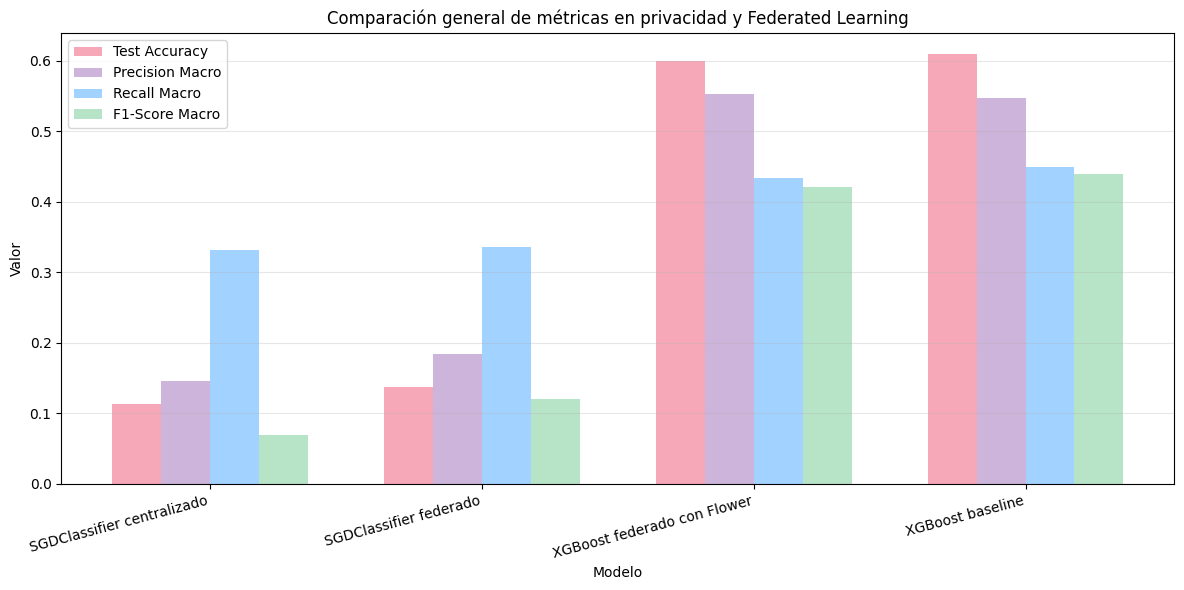

In [22]:
# Copia de seguridad del dataframe
df = resultados_privacidad.copy()

# Convertir F1 Weighted a numérico por si hay None
df["F1 Weighted"] = pd.to_numeric(df["F1 Weighted"], errors="coerce")

# Colores 
colors_metricas = ['#F7A8B8', '#CDB4DB', '#A2D2FF', '#B7E4C7']

# GRÁFICA COMPARATIVA GENERAL
metricas = ["Test Accuracy", "Precision Macro", "Recall Macro", "F1-Score Macro"]
modelos = df["Modelo"].tolist()

x = np.arange(len(modelos))
width = 0.18

plt.figure(figsize=(12, 6))

for i, metrica in enumerate(metricas):
    plt.bar(
        x + i * width,
        df[metrica],
        width=width,
        label=metrica,
        color=colors_metricas[i]
    )

plt.xticks(x + width * 1.5, modelos, rotation=15, ha="right")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.title("Comparación general de métricas en privacidad y Federated Learning")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica anterior confirma de forma visual el análisis realizado, ya que compara las métricas principales de los cuatro modelos evaluados. Se observa claramente que los modelos basados en "SGDClassifier" obtienen resultados bastante bajos en todas las métricas, lo que indica que este modelo lineal no se adapta bien al problema. En cambio, los dos modelos basados en XGBoost presentan un rendimiento mucho mejor en todas las métricas. El XGBoost baseline obtiene los mejores valores de forma general, pero el XGBoost federado queda muy cerca y teniendo en cuenta la ventaja en privacidad que aporta, se considera una opción muy competitiva.